## To create NN which can classify whether the given data belongs to which number.A number can range from 0 to 9.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import keras
from keras.datasets.mnist import load_data
import seaborn as sns

Loading the MNIST inbuilt dataset

In [ ]:
# data=keras.datasets.mnist
(X_train,y_train),(X_test,y_test)=load_data()

Validation data creation

In [ ]:
x_valid,x_train=X_train[:5000]/255,X_train[5000:]/255
y_valid,y_train=y_train[:5000],y_train[5000:]

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)
print(X_test.shape)
print(y_test.shape)

(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)
(10000, 28, 28)
(10000,)


Visualize the data

Building Model Architecture

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)
print(len(np.unique(y_train)))

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
LAYERS = [
          tf.keras.layers.Flatten(input_shape=[28, 28], name="InputLayer"),
          tf.keras.layers.Dense(500, activation="relu", name="HiddenLayer1"),
          tf.keras.layers.Dense(100, activation="relu", name="HiddenLayer2"),
          tf.keras.layers.Dense(10, activation="softmax", name="outputLayer"),

]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model = tf.keras.models.Sequential(LAYERS)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer1 (Dense)            │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer2 (Dense)            │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weights,bias = model.layers[1].get_weights()

In [ ]:
weights.shape

(784, 500)

In [ ]:
bias.shape

<Axes: ylabel='Density'>

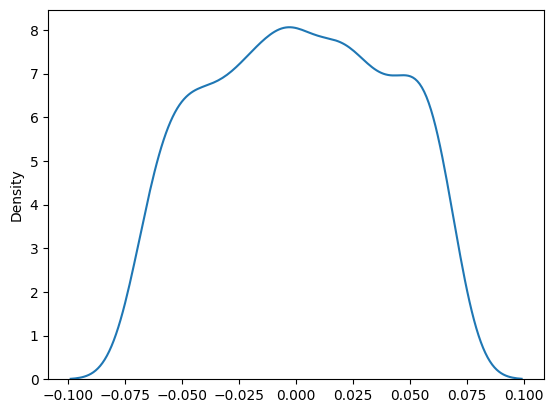

In [ ]:
sns.kdeplot(weights[:,1])

In [ ]:
LOSS_FUNCTION = "sparse_categorical_crossentropy"
OPTIMIZER = "adam"
METRICS = ["accuracy"]

model.compile(loss=LOSS_FUNCTION,
              optimizer=OPTIMIZER,
              metrics=METRICS)


### Important -

* **Epochs**: Integer.
    
    Number of epochs to train the model. An epoch is an iteration over the entire x and y data provided.

* **batch_size**: Integer or None.
    
    Number of samples per gradient update. If unspecified, batch_size will default to 32.
    
    *NOTE:* Do not specify the batch_size if your data is in the form of datasets, generators, or keras.utils.Sequence instances (since they generate batches).

* **validation_batch_size**: Integer or None.

    Number of samples per validation batch.
    
    If unspecified, will default to batch_size.
    
    *NOTE:* Do not specify the validation_batch_size if your data is in the form of datasets, generators, or keras.utils.Sequence instances (since they generate batches).

[Reference](https://www.tensorflow.org/api_docs/python/tf/keras/Model?hl=zh-tw#fit)

In [ ]:
 ## Training the model
EPOCHS = 10
VALIDATION_SET = (x_valid, y_valid)

history = model.fit(x_train, y_train,
                    epochs=EPOCHS,
                    validation_data=VALIDATION_SET)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9010 - loss: 0.3432 - val_accuracy: 0.9684 - val_loss: 0.1008
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9734 - loss: 0.0872 - val_accuracy: 0.9768 - val_loss: 0.0778
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0577 - val_accuracy: 0.9772 - val_loss: 0.0709
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9858 - loss: 0.0417 - val_accuracy: 0.9782 - val_loss: 0.0807
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9897 - loss: 0.0315 - val_accuracy: 0.9792 - val_loss: 0.0781
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9782 - val_loss: 0.0872
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9928 - loss: 0.0202 - val_accuracy: 0.9802 - val_loss: 0.0818
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9938 - loss: 0.0180 - 

In [ ]:
model.evaluate(X_test, y_test) ## evaluating model on testing data

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9753 - loss: 23.0740


[19.03325843811035, 0.9800000190734863]

In [ ]:
cv2_imshow(X_test[356])

In [ ]:
np.argmax(model.predict((X_test[356]/255).reshape(1,28,28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


np.int64(5)

In [ ]:
cv2_imshow(X_test[354])

In [ ]:
np.argmax(model.predict((X_test[354]/255).reshape(1,28,28)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


np.int64(1)

In [ ]:
model.save("abc.keras")  ## Saving the model

In [ ]:
loaded_model = tf.keras.models.load_model("/content/abc.keras") ## Loading the saved model

In [ ]:
history.history

In [ ]:
history.history['val_accuracy']

In [ ]:
history.history['accuracy']

In [ ]:
model.get_weights()

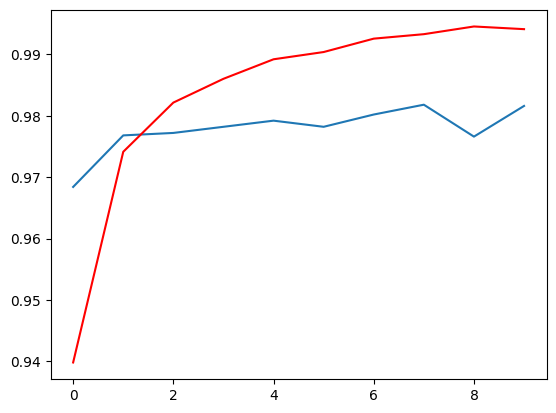

In [ ]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'],color = 'red')

In [ ]:
## Creating metrix for performance during training
import pandas as pd
pd.DataFrame(history.history)

In [ ]:
X_new = X_test[:3]
y_new = y_test[:3]
y_proba = model.predict(X_new)
y_proba


In [ ]:
import numpy as np
y_pred = np.argmax(y_proba, axis=-1)
y_pred, y_new

In [ ]:
for data, pred, actual in zip(X_new, y_pred, y_new):
  plt.imshow(data, cmap="binary")
  plt.title(f"Predicted: {pred}, Actual: {actual}")
  plt.axis("off")
  plt.show()
  print("---"*20)

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss,color='red')